In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data

data = pd.read_csv('../../datasets/data.csv')

data.head()

,city,district,neighborhood,room,living_room,area,age,floor,price
0,usak,banaz,cumhuriyet,3,1,150,20,-2,70
1,usak,merkez,kemaloz,2,1,110,8,1,85
2,usak,merkez,kemaloz,1,1,60,0,4,70
3,usak,merkez,durak,1,1,50,10,5,70
4,usak,merkez,cumhuriyet,4,1,300,11,7,165


In [2]:
print(data.shape)
print(data.columns)
print(data.describe())

(8136, 9)
Index(['city', 'district', 'neighborhood', 'room', 'living_room', 'area',
       'age', 'floor', 'price'],
      dtype='object')
              room  living_room         area          age        floor  \
count  8136.000000  8136.000000  8136.000000  8136.000000  8136.000000   
mean      2.402286     1.012168   131.274459    12.514626     2.284661   
std       1.284885     0.398182   177.969818    12.939832     2.078388   
min       1.000000     0.000000     5.000000     0.000000    -3.000000   
25%       2.000000     1.000000    80.000000     4.000000     1.000000   
50%       2.000000     1.000000   110.000000    10.000000     2.000000   
75%       3.000000     1.000000   145.000000    20.000000     3.000000   
max      41.000000    25.000000  9000.000000   600.000000    21.000000   

              price  
count  8.136000e+03  
mean   1.266101e+05  
std    1.698828e+06  
min    1.000000e+00  
25%    1.200000e+04  
50%    1.800000e+04  
75%    3.200000e+04  
max    1.200000e+0

In [3]:
# check for missing values
print(data.isnull().sum())

city            0
district        0
neighborhood    0
room            0
living_room     0
area            0
age             0
floor           0
price           0
dtype: int64


In [4]:
# turn some categorical variables into numerical

# check the unique values of the categorical variables on city column
print(data['city'].unique())

# check the unique values of the categorical
print(data.groupby('city')['city'].count())

['usak' 'afyonkarahisar' 'izmir' 'mugla' 'aydin' 'denizli' 'kutahya'
 'manisa']
city
afyonkarahisar      95
aydin              771
denizli            879
izmir             3678
kutahya             34
manisa             213
mugla             2444
usak                22
Name: city, dtype: int64


In [5]:
# turn some categorical variables into numerical

# check the unique values of the categorical variables on district column
print(data['district'].unique())

# check the unique values of the categorical
print(data.groupby('district')['district'].count())

['banaz' 'merkez' 'cay' 'dinar' 'bolvadin' 'suhut' 'tire' 'konak' 'selcuk'
 'karabaglar' 'torbali' 'balcova' 'menderes' 'narlidere' 'kemalpasa'
 'guzelbahce' 'buca' 'cigli' 'cesme' 'menemen' 'foca' 'karsiyaka'
 'bayrakli' 'bornova' 'karaburun' 'seferihisar' 'gaziemir' 'odemis'
 'dikili' 'urla' 'kinik' 'bergama' 'aliaga' 'bayindir' 'koycegiz' 'ortaca'
 'bodrum' 'milas' 'mentese' 'fethiye' 'dalaman' 'kavaklidere' 'ula'
 'marmaris' 'incirliova' 'kusadasi' 'nazilli' 'efeler' 'didim' 'soke'
 'cine' 'germencik' 'buharkent' 'merkezefendi' 'pamukkale' 'saraykoy'
 'civril' 'acipayam' 'cameli' 'cardak' 'tavas' 'honaz' 'kiraz' 'yatagan'
 'datca' 'seydikemer' 'tavsanli' 'simav' 'yunusemre' 'sehzadeler'
 'turgutlu' 'akhisar' 'salihli' 'saruhanli' 'soma' 'alasehir' 'demirci']
district
acipayam       2
akhisar       55
alasehir       3
aliaga         7
balcova      116
            ... 
turgutlu      44
ula           49
urla         131
yatagan        4
yunusemre     49
Name: district, Length: 77, dty

In [6]:
# turn some categorical variables into numerical

# check the unique values of the categorical variables on neighborhood column
print(data['neighborhood'].unique())

# check the unique values of the categorical
print(data.groupby('neighborhood')['neighborhood'].count())

['cumhuriyet' 'kemaloz' 'durak' 'unalan' 'fatih' 'ataturk' 'kurtulus'
 'hasan_karaagac' 'yenice' 'erenler' 'ali_ihsan_pasa'
 'erkmen_fevzi_cakmak' 'istiklal' 'kanlica' 'esentepe'
 'maresal_fevzi_cakmak' 'dortyol' 'sahipata' 'osman_gazi' 'asagi' 'aktas'
 'sirinevler' 'dumlupinar' 'veysel_karani' 'pinarli' 'dervis_pasa'
 'esrefpasa' 'imaret' 'marulcu' 'karsiyaka' 'haci_musa' 'yunus_emre'
 'kocatepe' 'nazmi_saatci' 'mecidiye' 'selcuklu' 'zafer' 'sazi' '4_eylul'
 'alsancak' '14_mayis' 'peker' 'yedi_eylul' 'koruturk'
 'gumuldur_fevzi_cakmak' 'muratbey' 'ilica' 'ulucak_mustafa_kemal_ataturk'
 'goztepe' 'mustafa_kemal_pasa' 'kurucesme' 'yeni_mahalle' 'alacati'
 'doganay' 'altinyunus' '16_eylul' 'fevzi_cakmak' 'adatepe'
 'kazim_karabekir' 'aydogdu' 'haciveli' 'bostanli' 'efeler' 'tepekule'
 'yenikale' 'guven' 'fevzipasa' 'balatcik' 'kazimdirik' 'adalet'
 'mordogan' 'erzene' 'kuner' 'colak_ibrahim_bey' 'cakabey' 'evka_4'
 'yaylacik' 'hurriyet' 'cetin_emec' 'mithatpasa' 'calikusu' 'candarli'
 'z

In [3]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to each categorical column
data['city'] = le.fit_transform(data['city'])
data['district'] = le.fit_transform(data['district'])
data['neighborhood'] = le.fit_transform(data['neighborhood'])

# Print the final dataframe
print("\nData after converting categorical columns to numerical:")
print(data)


Data after converting categorical columns to numerical:
      city  district  neighborhood  room  living_room  area  age  floor  \
0        7         5           166     3            1   150   20     -2   
1        7        49           418     2            1   110    8      1   
2        7        49           418     1            1    60    0      4   
3        7        49           204     1            1    50   10      5   
4        7        49           166     4            1   300   11      7   
...    ...       ...           ...   ...          ...   ...  ...    ...   
8131     6        55           318     3            1   151   10      2   
8132     6        73           277     3            1   130   20      2   
8133     6         9           641     3            1   130   12      2   
8134     6         9           143     2            1    90   31      0   
8135     6         9           284     3            1   285   13      1   

        price  
0          70  
1         

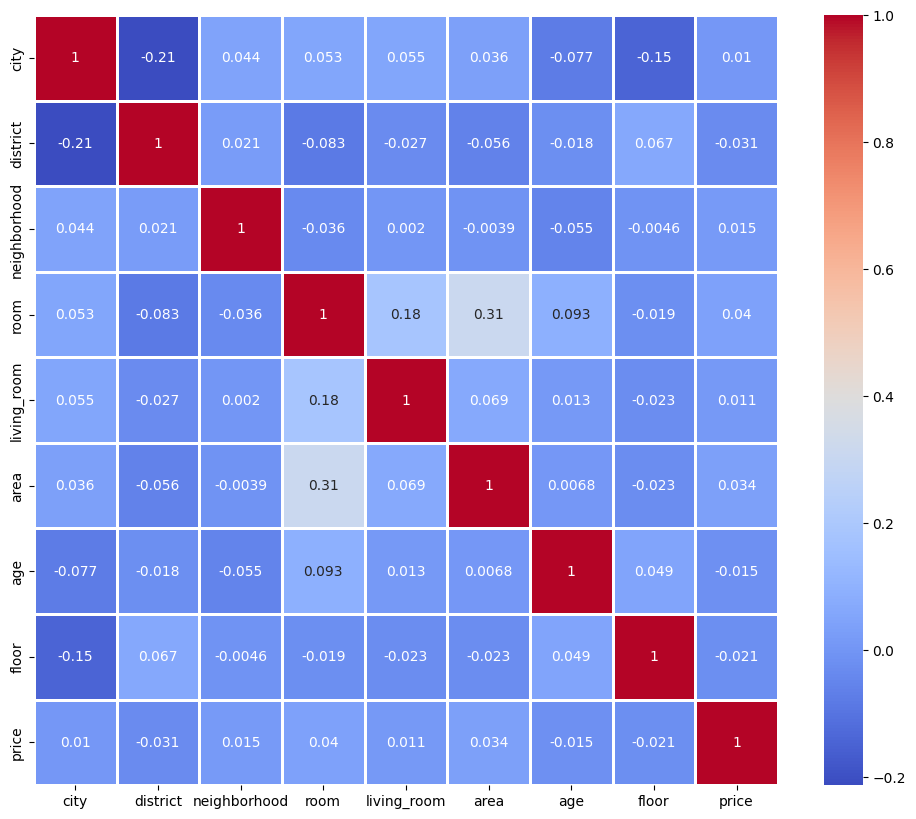

In [4]:
# create heatmap to check the correlation between the variables

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=2)
plt.show()

In [54]:
# Split the data into training and testing sets

train_data = data.sample(frac=0.8, random_state=42)
test_data = data.drop(train_data.index)

# Split the data into features and target

X_train = train_data.drop('price', axis=1)
y_train = train_data['price']

X_test = test_data.drop('price', axis=1)
y_test = test_data['price']

In [49]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('price', axis=1), data['price'], test_size=0.2, random_state=0)



In [ ]:
model.predict(X_test[0:5])

array([[776027.06031396],
       [-99862.54473464],
       [ 75568.08566786],
       [ 15468.15270958],
       [-79797.73736435]])

In [55]:
print(X_train.shape)
print(y_train.shape)

(6509, 8)
(6509,)


In [56]:
print(X_test.shape)
print(y_test.shape)

(1627, 8)
(1627,)


In [98]:
77641667.11437032 - 77912065.7754434

-270398.66107308865

In [57]:
# turn the data into numpy arrays

X_train = X_train.values
y_train = y_train.values

X_test = X_test.values
y_test = y_test.values



In [58]:
X_train = np.array(X_train).reshape(6509, 8)
y_train = np.array(y_train).reshape(6509, 1)

X_test = np.array(X_test).reshape(1627, 8)  
y_test = np.array(y_test).reshape(1627, 1)

In [59]:
X_train.shape
X_train[0]

array([  6,  48, 449,   1,   1,  50,   7,   0], dtype=int64)

In [173]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sys
import cupy

class PolyRegression():
    def __init__(self, train_inputs, train_outputs, degree):
        self.train_inputs = train_inputs
        self.train_outputs = train_outputs
        self.degree = degree
        # self.weights = np.zeros((self.degree + 1, 1))
        self.weights = np.zeros((train_inputs.shape[1] * self.degree + 1)) 
        self.bias = 0
        self.loss = []

    # def cost_func(self, prediction, train_output):
    #     return np.mean((prediction - train_output) ** 2)

    def cost_func(self, prediction, train_output, lambda_reg=0.1): 
        return np.mean((prediction - train_output) ** 2) + (lambda_reg * np.sum(np.abs(self.weights))) # L1 reg

    def transform_inputs(self, inputs):
        transformed_inputs = inputs
        for i in range(2, self.degree + 1):
            transformed_inputs = np.concatenate((transformed_inputs, inputs ** i), axis=1)
        transformed_inputs = np.concatenate((np.ones((transformed_inputs.shape[0], 1)), transformed_inputs), axis=1)
        return transformed_inputs

    # used transform and normalize function from here https://www.geeksforgeeks.org/polynomial-regression-from-scratch-using-python/?ref=lbp
    # def transform_inputs(self, X):
    #     # initialize X_transform
    #     X_transform = np.ones((X.shape[0], 1))

    #     for j in range(1, self.degree + 1):
    #         x_pow = np.power(X, j)
    #         # append x_pow to X_transform
    #         X_transform = np.append(X_transform, x_pow.reshape(-1, 1), axis=1)

    #     return X_transform
    
    def normalize_inputs(self, inputs):
        # Normalize the inputs
        mean = np.mean(inputs, axis=0)
        std = np.std(inputs, axis=0)
        # Avoid division by zero by setting std to 1 where std is 0
        std[std == 0] = 1
        return (inputs - mean) / std
    # def normalize_inputs( self, X ) :
         
    #     X[:, 1:] = ( X[:, 1:] - np.mean( X[:, 1:], axis = 0 ) ) / np.std( X[:, 1:], axis = 0 )
         
    #     return X

    def forward_propagation(self, inputs):
        return np.dot(inputs, self.weights) + self.bias

    def update_weights(self, prediction, train_output, normalized_inputs, learning_rate):
        prediction = prediction.reshape(-1, 1)
        train_output = train_output.reshape(-1, 1)

        # transformed_inputs = self.transform_inputs(self.train_inputs)
        # normalized_inputs = self.normalize_inputs(transformed_inputs)

        gradient_weights = np.dot(normalized_inputs.T, (prediction - train_output)) / normalized_inputs.shape[0]
        gradient_bias = np.mean(prediction - train_output)

        self.weights -= learning_rate * gradient_weights
        self.bias -= learning_rate * gradient_bias
    
    def train(self, learning_rate, iters):
        print(f"Initial shapes - train_inputs: {self.train_inputs.shape}, train_outputs: {self.train_outputs.shape}")

        transformed_inputs = self.transform_inputs(self.train_inputs)
        normalized_inputs = self.normalize_inputs(transformed_inputs)

        for i in range(iters):
            prediction = self.forward_propagation(normalized_inputs)
            cost = self.cost_func(prediction, self.train_outputs)
            self.update_weights(prediction, self.train_outputs, normalized_inputs, learning_rate)
            self.loss.append(cost)
            if i % 1000 == 0:
                print(f"Iteration {i}, cost={cost}")
            

        return self.weights, self.bias, self.loss
    # def train(self, learning_rate, iters):
    #     print(f"Initial shapes - train_inputs: {self.train_inputs.shape}, train_outputs: {self.train_outputs.shape}")

    #     fig, ax = plt.subplots()

    #     # Choose a specific column (feature) from train_inputs for plotting
    #     feature_index = 0  # Change this to the desired feature index
    #     ax.scatter(self.train_inputs[:, feature_index], self.train_outputs, label='Training data') 

    #     transformed_inputs = self.transform_inputs(self.train_inputs)
    #     normalized_inputs = self.normalize_inputs(transformed_inputs)

    #     # For plotting the fitted line, you might need to adjust this as well
    #     line, = ax.plot(self.train_inputs[:, feature_index], self.forward_propagation(normalized_inputs), color='red', label='Fit')
    #     logging.basicConfig(level=logging.INFO)
    #     def update(i):
    #         prediction = self.forward_propagation(normalized_inputs)
    #         cost = self.cost_func(prediction, self.train_outputs)
    #         self.update_weights(prediction, self.train_outputs, normalized_inputs, learning_rate)
    #         self.loss.append(cost)
    #         line.set_ydata(self.forward_propagation(normalized_inputs))
    #         # print("epoch, w, b, c: ", i, self.weights, self.bias, cost)
            
    #         logging.info(f"Iteration {i}, cost={cost}")
    #         # print(f"Iteration {i}, cost={cost}")
            
    #         return line,

    #     ani = FuncAnimation(fig, update, frames=iters, interval=200, blit=True)
    #     ani.save('linear_regression_20.gif', writer='ffmpeg')

    #     plt.xlabel('Input')
    #     plt.ylabel('Output')
    #     plt.title('Polynomial Regression')
    #     plt.legend()
    #     plt.show()

    #     return self.weights, self.bias, self.loss

    def predict(self, test_input):
        transformed_inputs = self.transform_inputs(test_input)  # Don't reshape here
        normalized_inputs = self.normalize_inputs(transformed_inputs)
        return np.dot(normalized_inputs, self.weights) + self.bias 

    def accuracy(self, test_input, test_output):
        prediction = self.predict(test_input)
        return 1 - self.cost_func(prediction, test_output) / np.mean(test_output ** 2)


ModuleNotFoundError: No module named 'cupy'

In [170]:
import logging
import numpy as np
import pandas as pd
import cupy as cp  # Use CuPy instead of NumPy 

class PolyRegression():
    def __init__(self, train_inputs, train_outputs, degree):
        self.train_inputs = cp.array(train_inputs)  # Move data to GPU
        self.train_outputs = cp.array(train_outputs) # Move data to GPU
        self.degree = degree
        self.weights = cp.zeros((train_inputs.shape[1] * self.degree + 1, 1))
        self.bias = 0
        self.loss = []

    def cost_func(self, prediction, train_output, lambda_reg=0.1): 
        return cp.mean((prediction - train_output) ** 2) + \
               (lambda_reg * cp.sum(cp.abs(self.weights)))

    def transform_inputs(self, inputs):
        transformed_inputs = inputs
        for i in range(2, self.degree + 1):
            transformed_inputs = cp.concatenate((transformed_inputs, inputs ** i), axis=1)
        transformed_inputs = cp.concatenate((cp.ones((transformed_inputs.shape[0], 1)), transformed_inputs), axis=1)
        return transformed_inputs

    def normalize_inputs(self, inputs):
        mean = cp.mean(inputs, axis=0)
        std = cp.std(inputs, axis=0)
        std[std == 0] = 1
        return (inputs - mean) / std

    def forward_propagation(self, inputs):
        return cp.dot(inputs, self.weights) + self.bias

    def update_weights(self, prediction, train_output, normalized_inputs, learning_rate):
        prediction = prediction.reshape(-1, 1)
        train_output = train_output.reshape(-1, 1)

        gradient_weights = cp.dot(normalized_inputs.T, (prediction - train_output)) / normalized_inputs.shape[0]
        gradient_bias = cp.mean(prediction - train_output)

        self.weights -= learning_rate * gradient_weights
        self.bias -= learning_rate * gradient_bias

    def train(self, learning_rate, iters):
        print(f"Initial shapes - train_inputs: {self.train_inputs.shape}, train_outputs: {self.train_outputs.shape}")

        transformed_inputs = self.transform_inputs(self.train_inputs)
        normalized_inputs = self.normalize_inputs(transformed_inputs)

        for i in range(iters):
            prediction = self.forward_propagation(normalized_inputs)
            cost = self.cost_func(prediction, self.train_outputs)
            self.update_weights(prediction, self.train_outputs, normalized_inputs, learning_rate)
            self.loss.append(cost.get())  # Retrieve cost from GPU to CPU for logging
            if i % 1000 == 0:
                print(f"Iteration {i}, cost={cost}")

        return self.weights, self.bias, self.loss 

    def predict(self, test_input):
        test_input = cp.array(test_input)  # Move data to GPU
        transformed_inputs = self.transform_inputs(test_input)
        normalized_inputs = self.normalize_inputs(transformed_inputs)
        return cp.dot(normalized_inputs, self.weights) + self.bias

    def accuracy(self, test_input, test_output):
        prediction = self.predict(test_input)
        return 1 - self.cost_func(prediction, cp.array(test_output)).get() / cp.mean(cp.array(test_output) ** 2).get()

ModuleNotFoundError: No module named 'cupy'

In [172]:
!pip install cupy

^C


In [174]:


# Create an instance of the PolyRegression class
model = PolyRegression(X_train, y_train, degree = 10)

# train the model
model.train(learning_rate=0.0001, iters=1000000)

# accuracy of the model

print("Train Accuracy: ", model.accuracy(X_test, y_test))



Initial shapes - train_inputs: (6509, 8), train_outputs: (6509, 1)
Iteration 0, cost=3594225581578.6094
Iteration 1000, cost=3583368653118.994
Iteration 2000, cost=3576160917466.3374
Iteration 3000, cost=3570579049432.393
Iteration 4000, cost=3566061494601.7935
Iteration 5000, cost=3562349946799.267
Iteration 6000, cost=3559279401259.0176
Iteration 7000, cost=3556727970087.1396
Iteration 8000, cost=3554600252191.0845
Iteration 9000, cost=3552819793755.2725
Iteration 10000, cost=3551324694275.5693
Iteration 11000, cost=3550064589997.991
Iteration 12000, cost=3548998391576.2656
Iteration 13000, cost=3548092514137.6265
Iteration 14000, cost=3547319465460.449
Iteration 15000, cost=3546656709677.786
Iteration 16000, cost=3546085748720.58
Iteration 17000, cost=3545591377904.9316
Iteration 18000, cost=3545161081787.9004
Iteration 19000, cost=3544784543226.3784
Iteration 20000, cost=3544453243654.63
Iteration 21000, cost=3544160138062.165
Iteration 22000, cost=3543899389759.03
Iteration 23000,

KeyboardInterrupt: 

: 

In [151]:
print("Train Accuracy: ", model.accuracy(X_test, y_test))


Train Accuracy:  -1.3753825407781743


In [164]:
print(X_test[0:1], y_test[0:1])
print(model.predict(X_test[0:1]))

[[  7   5 166   3   1 150  20  -2]] [[70]]
[[137480.60331848]]


In [149]:
model.predict(X_test[0:5])

array([[776027.06031396],
       [-99862.54473464],
       [ 75568.08566786],
       [ 15468.15270958],
       [-79797.73736435]])

Iteration 0, cost=3509929718026.1484
Iteration 0, cost=3501412187610.6387
Iteration 0, cost=3496259265450.61
Iteration 0, cost=3493054189689.0347
Iteration 100, cost=3486818883575.0757
Iteration 200, cost=3486645548374.289
Iteration 300, cost=3486566961194.975
Iteration 400, cost=3486514070672.2715
Iteration 500, cost=3486468654563.577
Iteration 600, cost=3486425814672.907
Iteration 700, cost=3486384168343.8916
Iteration 800, cost=3486343277365.6562
Iteration 900, cost=3486302969629.6895
Iteration 1000, cost=3486263156922.837
Iteration 1100, cost=3486223783611.563
Iteration 1200, cost=3486184810479.6094
Iteration 1300, cost=3486146208462.583
Iteration 1400, cost=3486107955497.29
Iteration 1500, cost=3486070034577.0273
Iteration 1600, cost=3486032432412.5674
Iteration 1700, cost=3485995138466.6934
Iteration 1800, cost=3485958144245.833
Iteration 1900, cost=3485921442777.0396
Iteration 2000, cost=3485885028220.92
Iteration 2100, cost=3485848895584.939
Iteration 2200, cost=3485813040510.9

KeyboardInterrupt: 

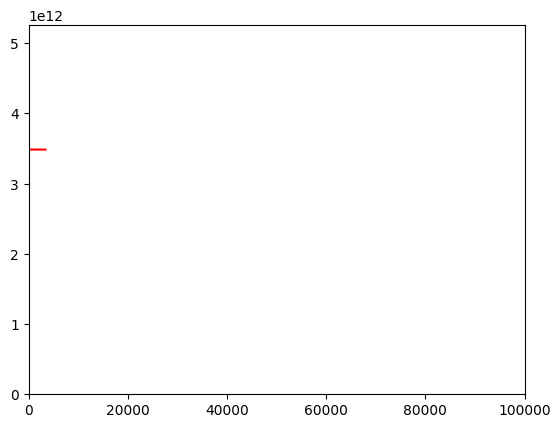

In [83]:
import sys
sys.path.append('../multiple_linear_regression/')
from mlr import LinearRegression

# train_size = 500
# test_size = 199

# data['Extracurricular Activities'] = data['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
# train_input = np.array(data[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']][:train_size]).reshape(train_size, 5)
# train_output = np.array(data['Performance Index'][:train_size]).reshape(train_size, 1)

# print("Train input shape:", train_input.shape)
# print("Train output shape:", train_output.shape)

# test_input = np.array(data[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']][train_size:train_size+test_size]).reshape(test_size, 5)
# test_output = np.array(data['Performance Index'][train_size:train_size+test_size]).reshape(test_size, 1)

# print("Test input shape:", test_input.shape)
# print("Test output shape:", test_output.shape)

# model = LinearRegression(train_input, train_output)
# parameters, bias, loss = model.train(learning_rate=0.0001, iters=50)

# accuracy = model.accuracy(test_input, test_output)

# print(f'Accuracy: {accuracy}')

model = LinearRegression(X_train, y_train)

parameters, bias, loss = model.train(learning_rate=0.00001, iters=100000)

accuracy = model.accuracy(X_test, y_test)

print(f'Accuracy: {accuracy}')

print(X_test[0:1], y_test[0:1])
print(model.predict(X_test[0:1]))


In [51]:
from sklearn.linear_model import LinearRegression

# Create an instance of the LinearRegression class
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = model.score(X_test, y_test)

print(f'Accuracy: {accuracy}')


Accuracy: 0.004483672798438976


In [99]:
# import sklearn polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# Create an instance of the PolynomialFeatures class
poly = PolynomialFeatures(degree=10)

# Transform the input data
X_train_poly = poly.fit_transform(X_train)  
X_test_poly = poly.fit_transform(X_test)
poly_model = LinearRegression()

# Train the model
poly_model.fit(X_train_poly, y_train)




ModuleNotFoundError: No module named 'sklearn.nonlinear_model'